In [1]:
from torch.utils.data import DataLoader
from torchvision import transforms
from progressBar import printProgressBar

import medicalDataLoader
import argparse
from utils import *
from UNet_Base import *
import random
import torch
import pdb
from torch import optim
from medpy.metric.binary import dc,hd,asd
from torch import nn
import torch.nn.functional as F
from f_loss import *
import matplotlib.pyplot as plt
import time 
from Model_Samy import *
from f_loss import *
from matplotlib import pyplot as plt 

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
#Hyperparameter 
batch_size = 12
batch_size_val = 3
lr =  0.0009    # Learning Rate
epoch = 100 # Number of epochs
num_classes = 4 # NUMBER OF CLASSES
modelName = 'Unet_Adam_bst{}_bsv{}_lr00009'.format(batch_size,batch_size_val)
a_label_smoothing = 0.2
patience = 3

In [4]:
print("~~~~~~~~~~~ Creating the UNet model ~~~~~~~~~~")
print(" Model Name: {}".format(modelName))

num_classes = 4 # NUMBER
## CREATION OF YOUR MODEL
net = UNet(num_classes)

print("Total params: {0:,}".format(sum(p.numel() for p in net.parameters() if p.requires_grad)))

~~~~~~~~~~~ Creating the UNet model ~~~~~~~~~~
 Model Name: Unet_Adam_bst12_bsv3_lr0003
Total params: 31,042,564


In [5]:
## DEFINE THE TRANSFORMATIONS TO DO AND THE VARIABLES FOR TRAINING AND VALIDATION
root_dir = './Data/'
print(' Dataset: {} '.format(root_dir))

transform = transforms.Compose([
    transforms.ToTensor(),
])

mask_transform = transforms.Compose([
    transforms.ToTensor()
])



train_set = medicalDataLoader.MedicalImageDataset('train',
                                                  root_dir,
                                                  transform=transform,
                                                  mask_transform=mask_transform,
                                                  augment=False,
                                                  equalize=False)

train_loader = DataLoader(train_set,
                          batch_size=batch_size,
                          worker_init_fn=np.random.seed(0),
                          num_workers=0,
                          shuffle=True)


val_set = medicalDataLoader.MedicalImageDataset('val',
                                                root_dir,
                                                transform=transform,
                                                mask_transform=mask_transform,
                                                augment=False,
                                                equalize=False)

val_loader = DataLoader(val_set,
                        batch_size=batch_size_val,
                        worker_init_fn=np.random.seed(0),
                        num_workers=0,
                        shuffle=False)

test_set = medicalDataLoader.MedicalImageDataset('test',
                                                root_dir,
                                                transform=transform,
                                                mask_transform=mask_transform,
                                                augment=False,
                                                equalize=False)

test_loader = DataLoader(test_set,
                        worker_init_fn=np.random.seed(0),
                        num_workers=0,
                        shuffle=False)

 Dataset: ./Data/ 


https://pythonguides.com/adam-optimizer-pytorch/ \
https://arxiv.org/pdf/2104.05788.pdf \
https://www.crcv.ucf.edu/wp-content/uploads/2020/01/Optimization-Algorithms-for-Deep-Learning-Based-Medical-Image-Seg.pdf \
https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CyclicLR.html \
https://reubensinha7.medium.com/cyclical-learning-rates-hyper-parameter-tuning-a9439733bf3 

In [6]:
# DEFINE YOUR OUTPUT COMPONENTS (e.g., SOFTMAX, LOSS FUNCTION, ETC)
softMax = torch.nn.Softmax()
CE_loss = torch.nn.CrossEntropyLoss(label_smoothing=a_label_smoothing)
DiceLossV2Train = DiceLossV2(n_classes=4)
DiceLoss = MultiClassDiceLoss([1,2,3])
DiceLossVal = DiceLossV2(n_classes=4)
optimizer = torch.optim.Adam(net.parameters(), lr=lr)
opt_name = "ADAM"
lrsName = "ADAM"
lambda1 = lambda epoch: 0.65 ** epoch
#scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda1)
#scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0005, max_lr=0.001, cycle_momentum=True,mode='triangular2',base_momentum=0.85 ,max_momentum=0.95)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

In [7]:
## PUT EVERYTHING IN GPU RESOURCES    
if torch.cuda.is_available():
    net.cuda()
    softMax.cuda()
    CE_loss.cuda()
    DiceLossV2Train.cuda()

In [8]:
### To save statistics ####
checkpoint_save_epoch = 50
lossTotalTraining = []
lossTotalVal = []
lrs = []
Best_loss_val = 1000
trigger_times = 0
BestEpoch = 0
directory = 'Results/Statistics/' + modelName

if os.path.exists(directory)==False:
    os.makedirs(directory)

In [9]:
## START THE TRAINING
## FOR EACH EPOCH

for i in range(epoch):
    net.train()
    lossEpoch = []
    lrEpoch = []
    num_batches = len(train_loader)

    ## FOR EACH BATCH
    for j, data in enumerate(train_loader):
        ### Set to zero all the gradients
        net.zero_grad()
        optimizer.zero_grad()

        ## GET IMAGES, LABELS and IMG NAMES
        images = data[0]
        labels = data[1]
        # img_names = data[2]

        ### From numpy to torch variables
        labels = to_var(labels)
        images = to_var(images)

        ################### Train ###################
        #-- The CNN makes its predictions (forward pass)
        net_predictions = net.forward(images)
        s_pred = softMax(net_predictions)
        #-- Compute the losses --#
        # THIS FUNCTION IS TO CONVERT LABELS TO A FORMAT TO BE USED IN THIS CODE

        segmentation_classes = getTargetSegmentation(labels)
        seg_one_hot = F.one_hot(segmentation_classes ,num_classes=4).permute(0, 3, 1, 2).float()

        # COMPUTE THE LOSS
        #pred_one = predToSegmentation(s_pred)
        #CE_loss_value = 0.4 * CE_loss(net_predictions, seg_one_hot) + 0.6 * DiceLoss(s_pred ,seg_one_hot)
        CE_loss_value = 0.4 * CE_loss(net_predictions, seg_one_hot) + 0.6 * DiceLossV2Train(net_predictions ,segmentation_classes, softmax=True)# XXXXXX and YYYYYYY are your inputs for the CE
        lossTotal = CE_loss_value

        # DO THE STEPS FOR BACKPROP (two things to be done in pytorch)
        CE_loss_value.backward()
        optimizer.step()
            
        
        # Update LR
        lr_step = optimizer.state_dict()["param_groups"][0]["lr"]
        lrEpoch.append(lr_step)

        # THIS IS JUST TO VISUALIZE THE TRAINING 
        lossEpoch.append(lossTotal.cpu().data.numpy())
        
        #scheduler.step()
        printProgressBar(j + 1, num_batches,
                         prefix="[Training] Epoch: {} ".format(i),
                         length=15,
                         suffix=" Loss: {:.4f}, lr: {} ".format(lossTotal,lr_step))
    # Update LR
    
    # Commente si tu veux utiliser juste le optimizer

    lossEpoch = np.asarray(lossEpoch)
    lossEpoch = lossEpoch.mean()

    lossVal = inference(net, val_loader, DiceLossVal, i)
    #scheduler.step(lossVal)
    lossTotalVal.append(lossVal)
    lossTotalTraining.append(lossEpoch)

    lrEpoch = np.asarray(lrEpoch)
    lrEpoch = lossEpoch.mean()
    lrs.append(lrEpoch)

    printProgressBar(num_batches, num_batches,
                         done="[Training] Epoch: {}, LossT: {:.4f}, LossV: {:.4f}".format(i, lossEpoch, lossVal))

    if not os.path.exists('./models/' + modelName):
            os.makedirs('./models/' + modelName)

    #if lossVal > Best_loss_val + 0.002:
    #    print('Early stopping!\nStart to test process.')
    #    torch.save(net.state_dict(), './models/' + modelName + '/' + str(i) + 'evalStagne3x_Epoch')
    #    break
     
    if lossVal > Best_loss_val:
            trigger_times += 1
            print('trigger times:', trigger_times)
            torch.save(net.state_dict(), './models/' + modelName + '/' + str(i) + 'evalStagne_Epoch')

            if trigger_times >= patience:
                print('Early stopping!\nStart to test process.')
                torch.save(net.state_dict(), './models/' + modelName + '/' + str(i) + 'evalStagne3x_Epoch')
                break
    else:
        print('trigger times: 0')
        trigger_times = 0

    Best_loss_val = lossVal


[Training] Epoch: 0 [DONE]                                            
[Inference] Segmentation Done DiceLoss 0.2297, Dice: [0.52138417 0.68651181 0.82214   ], Dice Mean: 0.6766786610683319
[Training] Epoch: 0, LossT: 0.4912, LossV: 0.2297                                                            
trigger times: 0
[Training] Epoch: 1 [DONE]                                            
[Inference] Segmentation Done DiceLoss 0.1969, Dice: [0.67867962 0.7033066  0.8380642 ], Dice Mean: 0.7400168050692901
[Training] Epoch: 1, LossT: 0.3597, LossV: 0.1969                                                            
trigger times: 0
[Training] Epoch: 2 [DONE]                                            
[Inference] Segmentation Done DiceLoss 0.1836, Dice: [0.66711215 0.74958022 0.87054098], Dice Mean: 0.7624111126394565
[Training] Epoch: 2, LossT: 0.3382, LossV: 0.1836                                                            
trigger times: 0
[Training] Epoch: 3 [DONE]                       

KeyboardInterrupt: 

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3))
fig.suptitle('lr:{} train_batch_size:{} val_batch:{}  optimizer:{} '.format(lr,batch_size,batch_size_val,opt_name))
ax1.plot(lossTotalTraining)
ax1.set_title('Training Loss')
ax2.plot(lossTotalVal)
ax2.set_title('Validation Loss')
ax3.plot(lrs)
ax3.set_title('LearnRate '+ lrsName)
plt.tight_layout()
plt.savefig("./Stats/"+modelName)

In [ ]:
inferenceTest(net, test_loader, "Modeonfgbur")


# Hyperparameter 
paraRegulDice = 1 \
batch_size = 8 \
batch_size_val = 3 \
lr = 0.001 \
epoch = 100 \
augment = False \ 
equalize = True \
num_classes = 4 \
modelName = 'Test_Model' 
# Functions (e.g., SOFTMAX, LOSS FUNCTION, ETC)
softMax = torch.nn.Softmax() \
CE_loss = torch.nn.CrossEntropyLoss() \
DiceLoss = MultiClassDiceLoss([1,2,3]) \
DiceLossVal = MultiClassDiceLoss([1,2,3]) \
optimizer = torch.optim.SGD(net.parameters(), lr=lr) 
# Train loss
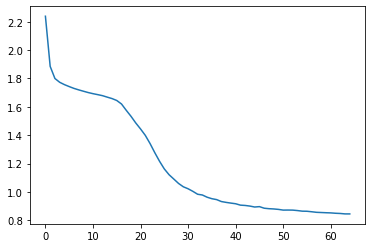 
[Inference] Segmentation Done DiceLoss 0.3356, Dice: 0.9845                                                  
[Training] Epoch: 62, LossT: 0.8480, LossV: 0.3356                                                           
[Training] Epoch: 63 [DONE]                                
[Inference] Segmentation Done DiceLoss 0.3355, Dice: 0.9845                                                  
[Training] Epoch: 63, LossT: 0.8450, LossV: 0.3355                                                           
[Training] Epoch: 64 [DONE]                                
[Inference] Segmentation Done DiceLoss 0.3460, Dice: 0.9845                                                  
[Training] Epoch: 64, LossT: 0.8449, LossV: 0.3460          